# Strategy Fixed-Effect Robustness

The strategy-only mixed model reports βs with analytic SEs that assume the random-effects
distribution is correctly specified. With N=20 parents, the population-level coefficients
could be sensitive to which specific parents happened to be in the sample.

Two diagnostics:

1. **Parent-level bootstrap** — resample the 20 parents with replacement, refit the model
   each time, and examine the bootstrap distribution of each β. A tight distribution means
   the effect is robust to which parents were sampled. A wide or zero-crossing distribution
   means the point estimate is carried by a few parents.

2. **Directional consistency** — for each strategy, count how many parents show the effect
   in the same direction as the population estimate. 18/20 consistent = genuine population
   signal. 12/20 = real on average but heterogeneous — the coefficient partly reflects
   which parents contributed more highlights for that strategy.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from statsmodels.formula.api import mixedlm

pd.set_option('display.max_columns', 40)
sns.set_theme(style='whitegrid', palette='muted')
print('Imports OK.')

Imports OK.


In [2]:
DATA_DIR   = Path('../data-exports/20260412_183830')
OUTPUT_DIR = DATA_DIR / 'highlight_analysis_output'
OUTPUT_DIR.mkdir(exist_ok=True)

df_sel = pd.read_csv(OUTPUT_DIR / 'df_sel.csv')

r5 = pd.read_csv(DATA_DIR / 'R5_highlights_coded', sep='\t')
r5.columns = r5.columns.str.strip()
r5 = r5.rename(columns={
    'highlight_id':      'selection_id',
    'Parent Motivation': 'parent_motivation',
    'Model Strategy':    'model_strategy',
})
r5 = r5[r5['selection_id'].notna() & (r5['selection_id'].astype(str).str.strip() != '')]
r5['parent_motivation'] = r5['parent_motivation'].replace(
    'Response Could Evoke Strong Emotion', 'Response Could Evoke Strong Emotions'
)
r5_dedup = r5.drop_duplicates(subset='selection_id', keep='first')

df_sel = df_sel.drop(columns=['parent_motivation', 'model_strategy'], errors='ignore')
df_sel = df_sel.merge(
    r5_dedup[['selection_id', 'parent_motivation', 'model_strategy']],
    on='selection_id', how='left'
)
df_sel['parent_id'] = df_sel['prolific_pid']

df_strat = df_sel[
    df_sel['model_strategy'].notna() & df_sel['highlight_sentiment'].notna()
].copy()

REF_STRATEGY = 'Prompted Suggestions'

def clean_label(s):
    s = re.sub(r'C\(model_strategy.*?\)\[T\.', '', s)
    return s.rstrip(']')

print(f'df_strat: {df_strat.shape}  ({df_strat["parent_id"].nunique()} parents)')
print(f'Strategy counts:')
display(df_strat['model_strategy'].value_counts())

df_strat: (245, 48)  (20 parents)
Strategy counts:


model_strategy
Prompted Suggestions           90
Emphasize Emotional Support    47
Redirect with Alternatives     22
Clarify Child's Intent         19
Emphasize Risk Awareness       17
Consider Age Group             16
Explain Problems in Prompt     11
Unprompted Suggestions         11
Encourage Introspection         5
Refuse Response and Explain     5
Defer to Resources              2
Name: count, dtype: int64

## Reference model

In [3]:
formula_strat = f'highlight_sentiment ~ C(model_strategy, Treatment("{REF_STRATEGY}"))'
r_ref = mixedlm(formula_strat, data=df_strat, groups=df_strat['parent_id']).fit(reml=True)

ref_fe = pd.DataFrame({
    'coef': r_ref.params,
    'se':   r_ref.bse,
    'z':    r_ref.tvalues,
    'p':    r_ref.pvalues,
})
ref_fe.index = [clean_label(i) for i in ref_fe.index]
ref_fe = ref_fe[ref_fe.index != 'Group Var']

print('=== Reference model: strategy-only fixed effects ===')
display(ref_fe.round(3))

=== Reference model: strategy-only fixed effects ===


,coef,se,z,p
Intercept,4.931,0.346,14.272,0.000
Clarify Child's Intent,0.471,0.370,1.272,0.203
Consider Age Group,-0.279,0.370,-0.755,0.451
Defer to Resources,0.147,0.948,0.155,0.877
Emphasize Emotional Support,0.336,0.282,1.193,0.233
Emphasize Risk Awareness,0.489,0.377,1.297,0.194
Encourage Introspection,-0.854,0.642,-1.331,0.183
Explain Problems in Prompt,0.171,0.463,0.370,0.711
Redirect with Alternatives,1.117,0.394,2.835,0.005
Refuse Response and Explain,1.350,0.661,2.042,0.041


## Parent-level bootstrap

Resample the 20 parents with replacement. Each bootstrap draw builds a dataset of
20 parents (some appearing 2–3 times, some absent). Duplicate draws get unique
`_boot_pid` suffixes so the mixed model treats each copy as a separate random effect.

The bootstrap distribution of each β shows how much the population estimate depends
on the specific 20 parents in this sample.

In [4]:
N_BOOT = 500
parent_ids = df_strat['parent_id'].unique()
rng = np.random.default_rng(42)
boot_coefs = []
n_failed = 0

for b in range(N_BOOT):
    sampled = rng.choice(parent_ids, size=len(parent_ids), replace=True)
    frames = []
    for i, pid in enumerate(sampled):
        sub = df_strat[df_strat['parent_id'] == pid].copy()
        sub['_boot_pid'] = f'{pid}__{i}'
        frames.append(sub)
    df_boot = pd.concat(frames, ignore_index=True)

    try:
        r_boot = mixedlm(
            formula_strat, data=df_boot, groups=df_boot['_boot_pid']
        ).fit(reml=True, method='lbfgs', disp=False)
        params = r_boot.params.drop('Group Var', errors='ignore')
        boot_coefs.append(params.to_dict())
    except Exception:
        n_failed += 1
        continue

boot_df = pd.DataFrame(boot_coefs)
boot_df.columns = [clean_label(c) for c in boot_df.columns]
print(f'Completed {len(boot_df)}/{N_BOOT} replicates  ({n_failed} failed)')

# Summary table
strat_cols = [c for c in boot_df.columns if c != 'Intercept']
rows = []
for col in strat_cols:
    vals = boot_df[col].dropna()
    pt   = ref_fe.loc[col, 'coef'] if col in ref_fe.index else np.nan
    lo, hi = np.percentile(vals, [2.5, 97.5])
    rows.append({
        'strategy':     col,
        'point_est':    round(pt, 3),
        'boot_mean':    round(vals.mean(), 3),
        'boot_2.5%':    round(lo, 3),
        'boot_97.5%':   round(hi, 3),
        'CI_includes_0': lo <= 0 <= hi,
    })

boot_summary = pd.DataFrame(rows).sort_values('point_est', ascending=False)
print('\nBootstrap summary (sorted by point estimate):')
display(boot_summary.reset_index(drop=True))

uncertain = boot_summary[boot_summary['CI_includes_0']]['strategy'].tolist()
if uncertain:
    print(f'\nCI includes 0 (uncertain direction): {uncertain}')
else:
    print('\nAll strategy CIs exclude 0.')

Completed 500/500 replicates  (0 failed)

Bootstrap summary (sorted by point estimate):


,strategy,point_est,boot_mean,boot_2.5%,boot_97.5%,CI_includes_0
0,Refuse Response and Explain,1.350,1.325,0.836,1.800,False
1,Redirect with Alternatives,1.117,1.062,0.352,1.772,False
2,Emphasize Risk Awareness,0.489,0.495,-0.615,1.689,True
3,Clarify Child's Intent,0.471,0.351,-0.903,1.327,True
4,Emphasize Emotional Support,0.336,0.297,-1.082,1.508,True
5,Explain Problems in Prompt,0.171,0.333,-1.060,2.306,True
6,Defer to Resources,0.147,0.126,-0.138,0.378,True
7,Consider Age Group,-0.279,-0.289,-1.889,1.117,True
8,Unprompted Suggestions,-0.387,-0.351,-2.291,1.276,True
9,Encourage Introspection,-0.854,-0.592,-2.359,1.260,True



CI includes 0 (uncertain direction): ['Emphasize Risk Awareness', "Clarify Child's Intent", 'Emphasize Emotional Support', 'Explain Problems in Prompt', 'Defer to Resources', 'Consider Age Group', 'Unprompted Suggestions', 'Encourage Introspection']


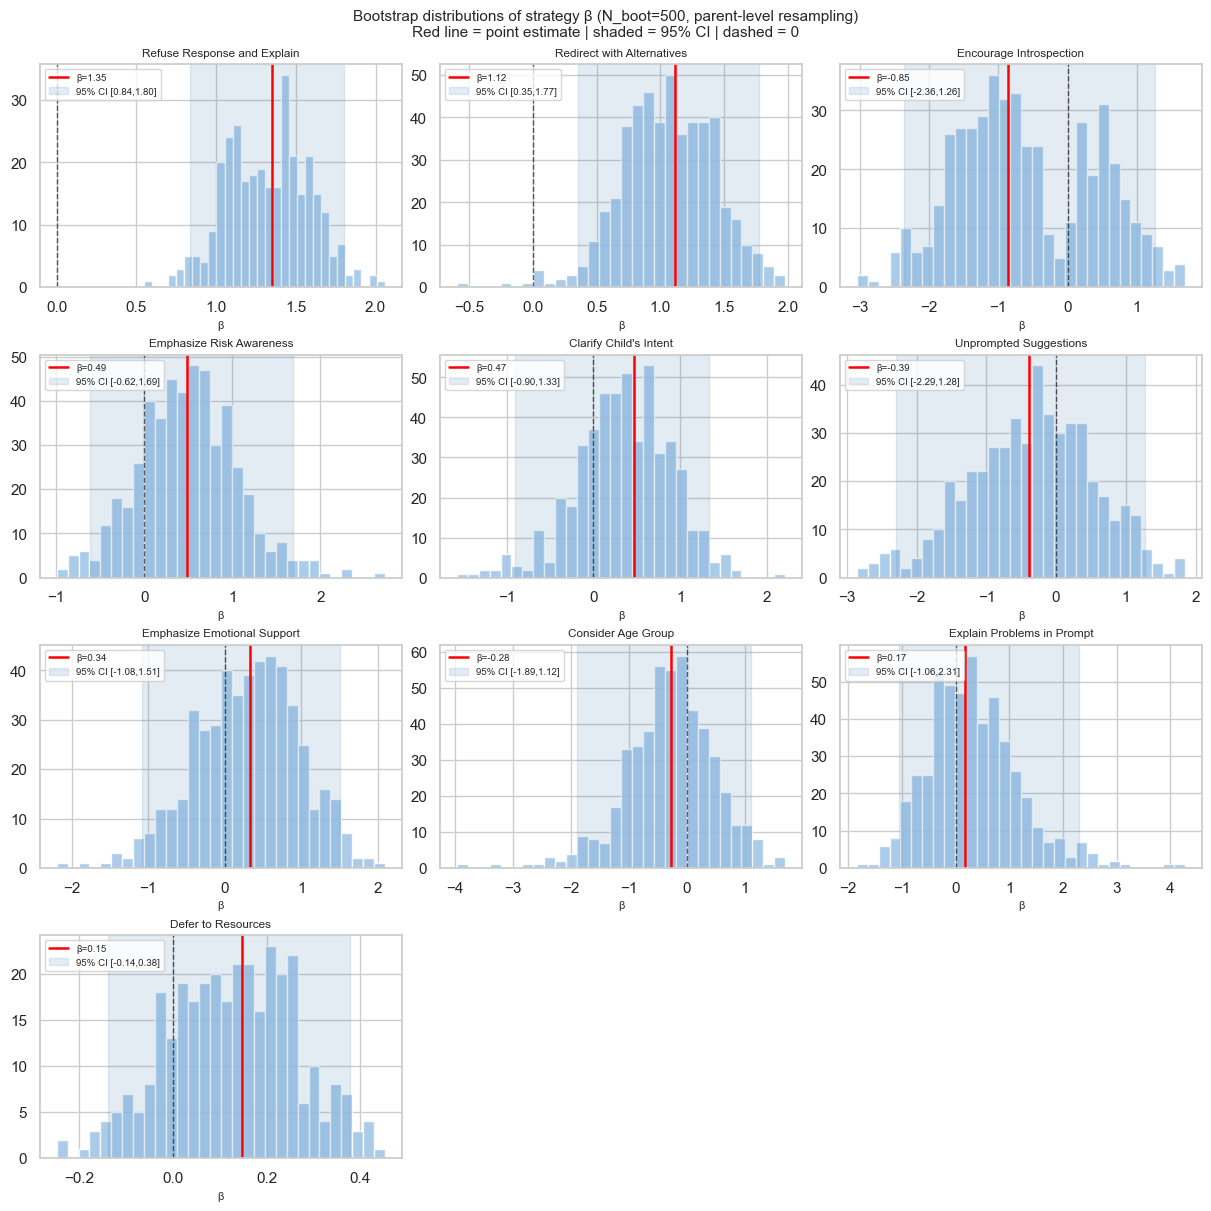

In [5]:
# Bootstrap distribution histograms, one per strategy coefficient
n_cols = 3
n_rows = int(np.ceil(len(strat_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(n_cols * 4, n_rows * 3),
                          constrained_layout=True)
axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

# Order by absolute point estimate descending
ordered = boot_summary.sort_values('point_est', key=abs, ascending=False)['strategy'].tolist()

for ax, col in zip(axes_flat, ordered):
    vals = boot_df[col].dropna()
    pt   = ref_fe.loc[col, 'coef'] if col in ref_fe.index else np.nan
    lo, hi = np.percentile(vals, [2.5, 97.5])

    ax.hist(vals, bins=30, color='#9DC3E6', edgecolor='white', alpha=0.85)
    ax.axvline(pt,  color='red',   lw=1.8, label=f'β={pt:.2f}')
    ax.axvline(0,   color='black', lw=1.0, linestyle='--', alpha=0.6)
    ax.axvspan(lo, hi, alpha=0.15, color='steelblue', label=f'95% CI [{lo:.2f},{hi:.2f}]')
    ax.set_title(col, fontsize=8.5)
    ax.legend(fontsize=7, loc='upper left')
    ax.set_xlabel('β', fontsize=8)
    ax.set_ylabel('')

# Hide unused subplots
for ax in axes_flat[len(ordered):]:
    ax.set_visible(False)

fig.suptitle(
    f'Bootstrap distributions of strategy β (N_boot={len(boot_df)}, parent-level resampling)\n'
    'Red line = point estimate | shaded = 95% CI | dashed = 0',
    fontsize=11
)
plt.savefig(OUTPUT_DIR / 'strategy_bootstrap_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## Directional consistency

For each strategy, compute a within-parent effect: the difference between a parent's mean
sentiment when they saw that strategy versus their mean for all other strategies.
Then compare the sign of that within-parent effect to the sign of the population β.

- **High consistency (≥70%)**: effect is genuine and present across most parents
- **Moderate (50–70%)**: real on average but heterogeneous
- **Low (<50%)**: population coefficient is driven by a subset of parents or by which
  parents happened to contribute more highlights for that strategy

In [6]:
pop_sign = {
    col: np.sign(ref_fe.loc[col, 'coef'])
    for col in ref_fe.index
    if col != 'Intercept' and col in ref_fe.index
}

dir_rows = []
for strategy, p_sign in pop_sign.items():
    n_consistent = 0
    n_data = 0
    for pid in parent_ids:
        sub = df_strat[df_strat['parent_id'] == pid]
        mask_s = sub['model_strategy'] == strategy
        if mask_s.sum() < 1 or (~mask_s).sum() < 1:
            continue   # parent has no data for this strategy or no comparison data
        mean_s     = sub.loc[mask_s,  'highlight_sentiment'].mean()
        mean_other = sub.loc[~mask_s, 'highlight_sentiment'].mean()
        within_effect = mean_s - mean_other
        n_data += 1
        if np.sign(within_effect) == p_sign:
            n_consistent += 1

    pop_beta = ref_fe.loc[strategy, 'coef'] if strategy in ref_fe.index else np.nan
    dir_rows.append({
        'strategy':      strategy,
        'pop_beta':      round(pop_beta, 3),
        'n_data':        n_data,
        'n_consistent':  n_consistent,
        'pct_consistent': round(n_consistent / n_data * 100, 1) if n_data > 0 else np.nan,
    })

dir_df = pd.DataFrame(dir_rows).sort_values('pop_beta', ascending=False)
print('=== Directional consistency: strategy fixed effects ===')
display(dir_df.reset_index(drop=True))
dir_df.to_csv(OUTPUT_DIR / 'strategy_directional_consistency.csv', index=False)
print('Saved: strategy_directional_consistency.csv')

=== Directional consistency: strategy fixed effects ===


,strategy,pop_beta,n_data,n_consistent,pct_consistent
0,Refuse Response and Explain,1.350,1,1,100.0
1,Redirect with Alternatives,1.117,5,3,60.0
2,Emphasize Risk Awareness,0.489,7,3,42.9
3,Clarify Child's Intent,0.471,9,6,66.7
4,Emphasize Emotional Support,0.336,13,7,53.8
5,Explain Problems in Prompt,0.171,6,2,33.3
6,Defer to Resources,0.147,1,1,100.0
7,Consider Age Group,-0.279,7,4,57.1
8,Unprompted Suggestions,-0.387,6,3,50.0
9,Encourage Introspection,-0.854,3,1,33.3


Saved: strategy_directional_consistency.csv


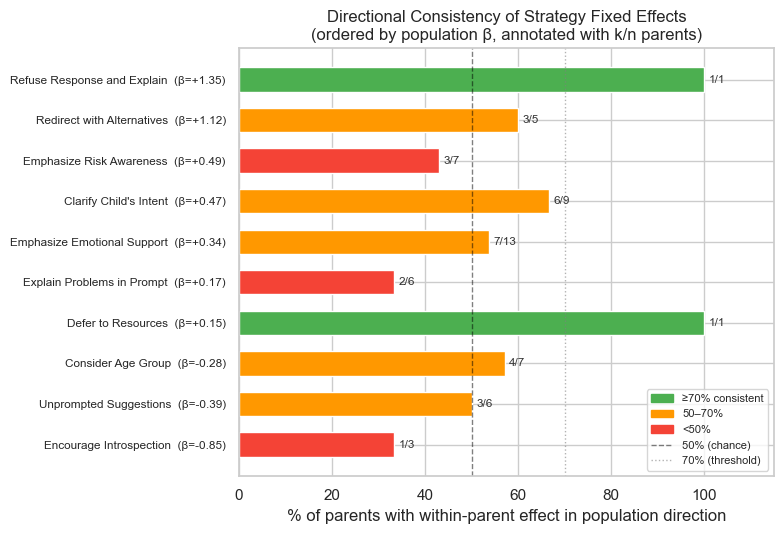

In [7]:
plot_dir = dir_df[dir_df['n_data'] > 0].sort_values('pop_beta', ascending=True)

def consistency_color(pct):
    if pd.isna(pct): return '#CCCCCC'
    if pct >= 70:    return '#4CAF50'   # green
    if pct >= 50:    return '#FF9800'   # orange
    return '#F44336'                    # red

colors = [consistency_color(p) for p in plot_dir['pct_consistent']]

fig, ax = plt.subplots(figsize=(8, max(5, len(plot_dir) * 0.55)))
y = list(range(len(plot_dir)))

ax.barh(y, plot_dir['pct_consistent'], color=colors, height=0.6, edgecolor='white')

for i, (_, row) in enumerate(plot_dir.iterrows()):
    if pd.notna(row['pct_consistent']):
        ax.text(
            row['pct_consistent'] + 1, i,
            f"{int(row['n_consistent'])}/{int(row['n_data'])}",
            va='center', fontsize=8.5, color='#333333'
        )

ax.axvline(50, color='black', linestyle='--', lw=1.0, alpha=0.5, label='50% (chance)')
ax.axvline(70, color='gray',  linestyle=':',  lw=1.0, alpha=0.6, label='70% (threshold)')
ax.set_xlim(0, 115)
ax.set_yticks(y)
ax.set_yticklabels(
    [f'{row["strategy"]}  (β={row["pop_beta"]:+.2f})'
     for _, row in plot_dir.iterrows()],
    fontsize=8.5
)
ax.set_xlabel('% of parents with within-parent effect in population direction')
ax.set_title(
    'Directional Consistency of Strategy Fixed Effects\n'
    '(ordered by population β, annotated with k/n parents)'
)

patches = [
    mpatches.Patch(color='#4CAF50', label='≥70% consistent'),
    mpatches.Patch(color='#FF9800', label='50–70%'),
    mpatches.Patch(color='#F44336', label='<50%'),
]
handles, labels_ = ax.get_legend_handles_labels()
ax.legend(handles=patches + handles, fontsize=8, loc='lower right')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'strategy_directional_consistency.png', dpi=150, bbox_inches='tight')
plt.show()

## Synthesis

Read the two diagnostics together:

- **Bootstrap CI excludes 0 + high directional consistency (≥70%)**: the effect is robust
  to which parents were sampled and present across most of the sample. This is as strong
  as N=20 evidence gets.

- **Bootstrap CI excludes 0 + moderate consistency (50–70%)**: the population effect is
  likely real but heterogeneous. The β reflects an average over parents whose individual
  effects vary in magnitude and may be near zero for many.

- **Bootstrap CI includes 0 or low consistency (<50%)**: the point estimate is not reliable.
  It may be driven by a small number of parents or by uneven coverage of highlights across
  parents. Do not interpret the β as a population-level signal.

Both diagnostics operate on the same N=20 parent ceiling. Even effects that pass both
checks should be reported with parent-clustered (bootstrap) CIs rather than analytic SEs,
so the external-validity constraint is visible in any summary table.